# β y la penalización de las categorías grandes: dónde quedan las quinasas


El barrido del notebook `01` deja a **β = 1** como óptimo en 10 de las 16
especies, y `02` muestra que β es el único de los cuatro parámetros que mueve la
AUC01 de forma consistente. Lo que β hace en el modelo es penalizar las
categorías grandes: una anotación que comparte media proteína del genoma aporta
menos que una específica. β = 0 apaga esa penalización — es la diferencia entre
G′r y G′rk (CONVENCIONES.md §5).

Este notebook pregunta **sobre quién** actúa esa penalización, usando a las
quinasas como caso de prueba: son el ejemplo de libro de una categoría grande y
promiscua (391 de los 14 083 dominios, pero 6.7 % de las proteínas anotadas) y
están sobrerrepresentadas entre los blancos con bioactividad conocida.

El contraste se hace a **parámetros controlados**: para cada especie se toma el
mejor (α, λ, γ) del barrido *dentro de* β = 1, y después se mueve **sólo** β a 0.
Si cada β se quedara con su propio óptimo global cambiarían los cuatro
parámetros a la vez y el efecto de β no se podría separar del de los otros tres.

Qué anotación es de quinasa no se puede decidir desde `DB/` —`ann` es un entero
codificado— así que la marca vive en `comun/tdr.py` como `ANN_QUINASA`: los 391
códigos, con el accession de InterPro al lado para poder auditarla. Es una
revelación parcial y deliberada del diccionario privado, la única
(PROVENANCE.md §3.15); `datos_externos/quinasas/derivar.py` es su procedencia.
De acá para abajo el análisis usa **sólo** el código.

Salidas: `03_params_comparacion.csv`, `03_resumen_beta.csv`,
`03_desplazamiento.csv`, `03_quinasas.csv`.


## Imports


In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "genome_prioritization"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_genome as fg              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("genome_prioritization")
FIGURAS = SALIDAS / "figuras"
NB      = "03"                             # numero de este notebook: prefija todo lo que genere

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out')

## Datos


In [2]:
BARRIDO = tdr.out("genome_prioritization")             # salidas del notebook 01
barrido = fg.cargar_barrido(BARRIDO, "01")
datos   = tdr.cargar_db(anotaciones=True, cluster_consistent=False)

quinasas = tdr.anotaciones_quinasa()                   # tdr.ANN_QUINASA, con prefijo IP

# cuanto de la capa de anotaciones alcanza la marca, medido contra la base
dom = datos.sta[datos.sta["db"] == "ip"]
q_dom = dom[dom["ann"].isin(set(quinasas))]
print(f"{len(quinasas)} anotaciones de quinasa sobre {dom['ann'].nunique()} dominios "
      f"({100 * q_dom['ann'].nunique() / dom['ann'].nunique():.2f} %), en "
      f"{q_dom['target_id'].nunique()} de {dom['target_id'].nunique()} proteinas "
      f"({100 * q_dom['target_id'].nunique() / dom['target_id'].nunique():.2f} %)")
print(f"barrido: {barrido.shape}")

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


391 anotaciones de quinasa sobre 14083 dominios (2.78 %), en 13904 de 206251 proteinas (6.74 %)
barrido: (1920, 10)


## Acondicionamiento


In [3]:
# el mejor (alpha, lambda_, gamma) de cada especie DENTRO de beta = 1; despues
# solo se mueve beta, para que el contraste no confunda a beta con los otros tres
params = fg.params_a_beta_fijo(barrido, fg.BETA_ALTO)

# vista de entrada: sobre que se va a correr, y cuanta quinasa tiene cada genoma
# `sta` ya trae sp_id: no hace falta cruzarla contra `st`
q_por_sp = (datos.sta[datos.sta["ann"].isin(set(quinasas))]
            .groupby("sp_id")["target_id"].nunique().rename("n_quinasas"))

entrada = (params.merge(tdr.META, left_on="especie", right_on="sp", how="left")
           .drop(columns=["sp"])
           .assign(n_quinasas=lambda d: d["especie"].map(q_por_sp).fillna(0).astype(int)))
entrada[["especie", "nombre", "grupo", "AUC01", "alpha", "beta", "lambda_", "gamma", "n_quinasas"]]

,especie,nombre,grupo,AUC01,alpha,beta,lambda_,gamma,n_quinasas
0,0,M. tuberculosis,Bacterias,0.580825,1.2,1.0,NaN,0.8,66
1,1,E. coli,Bacterias,0.587958,1.2,1.0,1.0,0.8,106
2,3,H. sapiens,Mamiferos,0.586040,0.0,1.0,1.0,0.8,582
3,4,T. cruzi,Protozoos,0.849387,0.0,1.0,1.0,0.8,524
4,5,S. aureus,Bacterias,0.566739,1.2,1.0,0.0,0.8,60
5,9,C. elegans,Invertebrados,0.657776,0.0,1.0,0.5,0.8,891
6,10,S. cerevisiae,Hongos,0.570765,0.3,1.0,0.5,0.8,208
7,15,T. brucei,Protozoos,0.771248,0.0,1.0,NaN,1.0,249
8,17,D. melanogaster,Invertebrados,0.614049,0.0,1.0,1.0,0.8,398
9,18,M. musculus,Mamiferos,0.610904,0.3,1.0,NaN,0.8,624


## Corrida


In [4]:
# el ciclo del analisis: por especie, el contexto una vez (semilla LOSO, Fisher,
# relevance score) y despues `nds` una vez por beta. La parte cara no depende de
# beta, asi que las dos corridas comparten todo salvo la propagacion.
resumen, desplaz, quinasas_filas = [], [], []

for _, r in params.iterrows():
    sp = int(r["especie"])
    lam = None if pd.isna(r["lambda_"]) else r["lambda_"]
    ctx = fg.preparar_especie(datos, sp)
    tabla, aucs = fg.ranking_por_beta(datos, ctx, r["alpha"], lam, r["gamma"],
                                      quinasas=quinasas)

    resumen.append(fg.resumen_beta(tabla, aucs, sp))
    desplaz.extend(fg.desplazamiento(tabla, sp))
    # de la tabla por proteina se versiona solo la parte de quinasas: es lo que
    # las figuras de distribucion necesitan, y son ~14 000 filas en vez de ~400 000
    quinasas_filas.append(tabla[tabla["quinasa"]])

    print(f"  {tdr.NOMBRE_CORTO[sp]}: AUC01 {aucs[fg.BETA_ALTO]:.4f} (beta=1) "
          f"vs {aucs[fg.BETA_NULO]:.4f} (beta=0), {int(tabla['quinasa'].sum())} quinasas",
          flush=True)

resumen = pd.DataFrame(resumen)
desplaz = pd.DataFrame(desplaz)
qtab    = pd.concat(quinasas_filas, ignore_index=True)

params.to_csv(SALIDAS / f"{NB}_params_comparacion.csv", index=False)
resumen.to_csv(SALIDAS / f"{NB}_resumen_beta.csv", index=False)
desplaz.to_csv(SALIDAS / f"{NB}_desplazamiento.csv", index=False)
qtab.to_csv(SALIDAS / f"{NB}_quinasas.csv", index=False)
fg.escribir_meta(SALIDAS, NB, notebook="03_comparacion_beta_promiscuidad.ipynb",
                 betas=[fg.BETA_ALTO, fg.BETA_NULO], top_k=fg.TOP_K,
                 barrido_nb="01", n_anotaciones_quinasa=len(quinasas))

  M. tuberculosis: AUC01 0.5808 (beta=1) vs 0.5453 (beta=0), 66 quinasas


  E. coli: AUC01 0.5880 (beta=1) vs 0.5308 (beta=0), 106 quinasas


  H. sapiens: AUC01 0.5860 (beta=1) vs 0.5818 (beta=0), 582 quinasas


  T. cruzi: AUC01 0.8494 (beta=1) vs 0.5739 (beta=0), 524 quinasas


  S. aureus: AUC01 0.5667 (beta=1) vs 0.5314 (beta=0), 60 quinasas


...

  C. albicans: AUC01 0.6453 (beta=1) vs 0.6018 (beta=0), 175 quinasas


  P. falciparum: AUC01 0.7365 (beta=1) vs 0.6789 (beta=0), 142 quinasas


  O. sativa: AUC01 0.6443 (beta=1) vs 0.5857 (beta=0), 1549 quinasas


  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/03_meta.json


{'notebook': '03_comparacion_beta_promiscuidad.ipynb',
 'nb': '03',
 'fecha': '2026-09-21 16:46',
 'params': None,
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'betas': [1.0, 0.0],
 'top_k': 100,
 'barrido_nb': '01',
 'n_anotaciones_quinasa': 391}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_genome.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py genome_prioritization


In [5]:
resumen = pd.read_csv(SALIDAS / f"{NB}_resumen_beta.csv")
desplaz = pd.read_csv(SALIDAS / f"{NB}_desplazamiento.csv")
qtab    = pd.read_csv(SALIDAS / f"{NB}_quinasas.csv")

resumen[["especie", "auc01_b1", "auc01_b0", "delta_auc01",
         "pct_quinasa_mediana_b1", "pct_quinasa_mediana_b0",
         "quinasas_top100_b1", "quinasas_top100_b0"]]

,especie,auc01_b1,auc01_b0,delta_auc01,pct_quinasa_mediana_b1,pct_quinasa_mediana_b0,quinasas_top100_b1,quinasas_top100_b0
0,0,0.580825,0.545261,0.035564,23.170432,21.316306,2.0,0.0
1,1,0.587958,0.530766,0.057192,16.526920,14.044572,1.0,0.0
2,3,0.586040,0.581838,0.004203,23.253067,2.113497,3.0,97.0
3,4,0.849387,0.573948,0.275439,13.661642,1.353950,0.0,100.0
4,5,0.566739,0.531442,0.035298,21.797804,19.819305,2.0,0.0
5,9,0.657776,0.553283,0.104492,16.593130,1.620843,0.0,100.0
6,10,0.570765,0.580898,-0.010133,22.316152,14.038903,2.0,0.0
7,15,0.771248,0.530155,0.241094,14.822753,1.355422,7.0,100.0
8,17,0.614049,0.559759,0.054290,26.884234,1.874883,1.0,100.0
9,18,0.610904,0.567695,0.043209,22.368566,18.895733,0.0,0.0


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/03_f01_auc01_beta.pdf


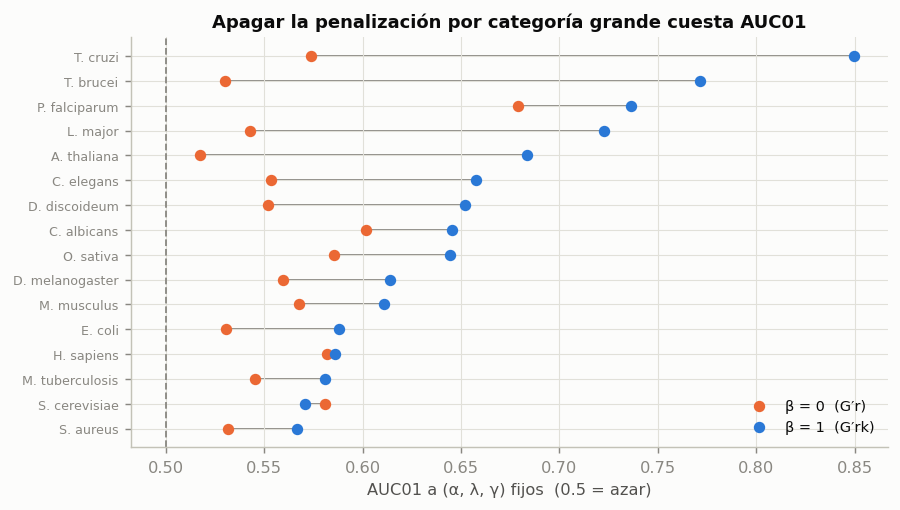

In [6]:
# Lo primero que hay que fijar: mover beta de 1 a 0 cuesta AUC01 en casi todas
F.dibujar("03_f01_auc01_beta");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/03_f02_percentil_quinasas.pdf


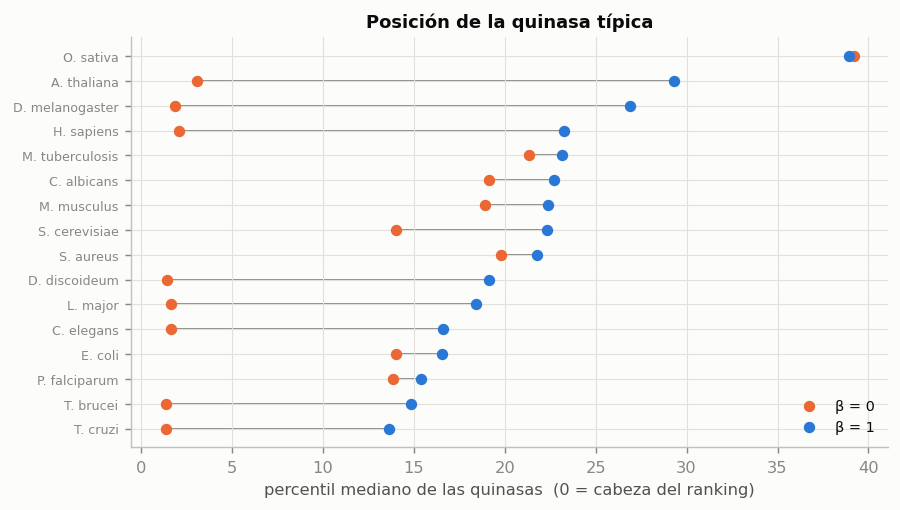

In [7]:
# Donde cae la quinasa tipica bajo cada beta (0 = cabeza del ranking)
F.dibujar("03_f02_percentil_quinasas");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/03_f03_desplazamiento.pdf


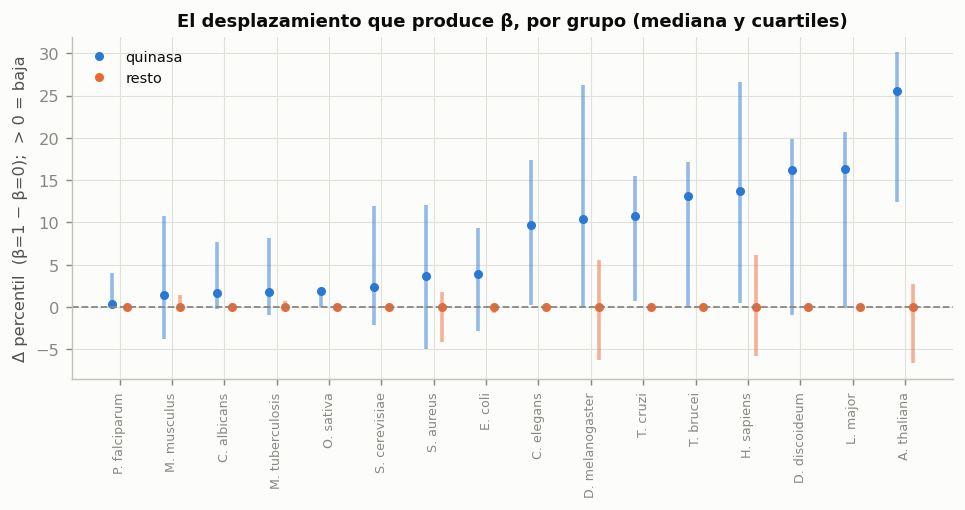

In [8]:
# El desplazamiento es especifico de las quinasas, o le pasa a todo el genoma?
F.dibujar("03_f03_desplazamiento");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/03_f04_enriquecimiento_top100.pdf


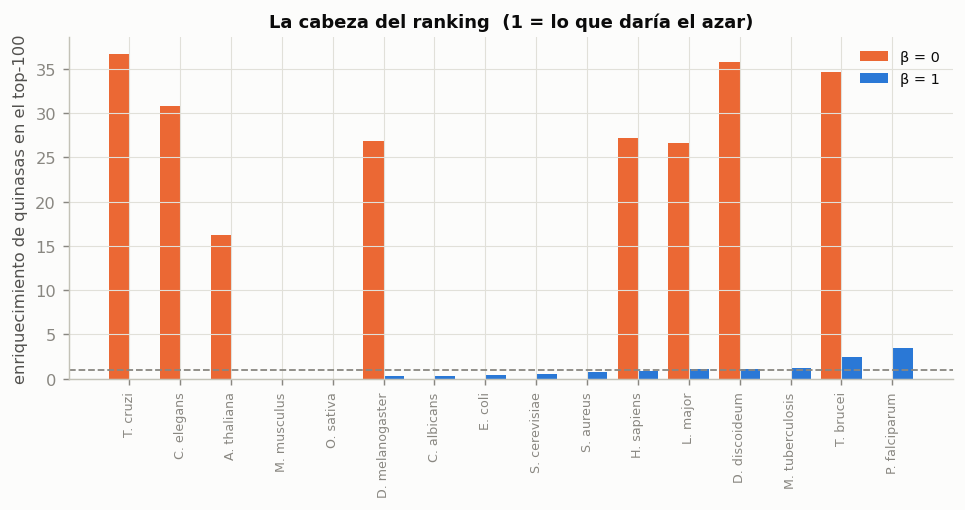

In [9]:
# La cabeza del ranking, que es lo que un grupo experimental miraria
F.dibujar("03_f04_enriquecimiento_top100");